<a href="https://colab.research.google.com/github/xesmaze/FieldDesigns-Summer2025/blob/main/Summer2026/FieldMapUpdate_SCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

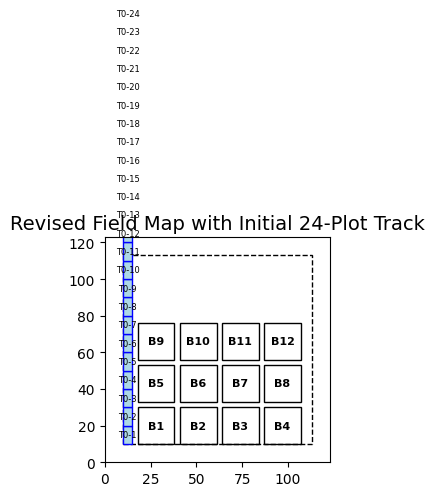

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Field parameters
field_width = 123
field_height = 123
border = 10
plot_length = 10
planted_length = 8
track_width = 5
row_spacing = 1.25  # 15" row spacing = 1.25 ft

# Plotting parameters
plots_per_track = 8
tracks_per_block = 2
blocks_per_row = 4
block_rows = 3
plot_width = row_spacing * 4  # 4-row planter
inter_block_space = 3
block_width = plot_width * plots_per_track / 2 + inter_block_space
block_height = plot_length * tracks_per_block + inter_block_space

# Start plotting
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xlim(0, field_width)
ax.set_ylim(0, field_height)
ax.set_title("Revised Field Map with Initial 24-Plot Track", fontsize=14)

# Draw border
field_rect = patches.Rectangle((border, border), field_width - 2 * border, field_height - 2 * border,
                               linewidth=1, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(field_rect)

# Draw initial track of 24 plots on the left edge
for i in range(24):
    y_start = border + i * plot_length
    rect = patches.Rectangle((border, y_start), plot_width, plot_length,
                             linewidth=1, edgecolor='blue', facecolor='lightblue')
    ax.add_patch(rect)
    ax.text(border + plot_width / 2, y_start + plot_length / 2, f"T0-{i+1}", ha='center', va='center', fontsize=6)

# Draw the rest of the field design starting to the right of the first track
start_x = border + plot_width + inter_block_space
start_y = border

for row in range(block_rows):
    for col in range(blocks_per_row):
        block_x = start_x + col * block_width
        block_y = start_y + row * block_height
        # Draw block boundary
        block_rect = patches.Rectangle((block_x, block_y), block_width - inter_block_space, block_height - inter_block_space,
                                       linewidth=1, edgecolor='black', facecolor='none')
        ax.add_patch(block_rect)
        ax.text(block_x + (block_width - inter_block_space) / 2, block_y + (block_height - inter_block_space) / 2,
                f"B{row * blocks_per_row + col + 1}", ha='center', va='center', fontsize=8, weight='bold')

ax.set_aspect('equal')
plt.grid(False)
plt.tight_layout()
plt.show()


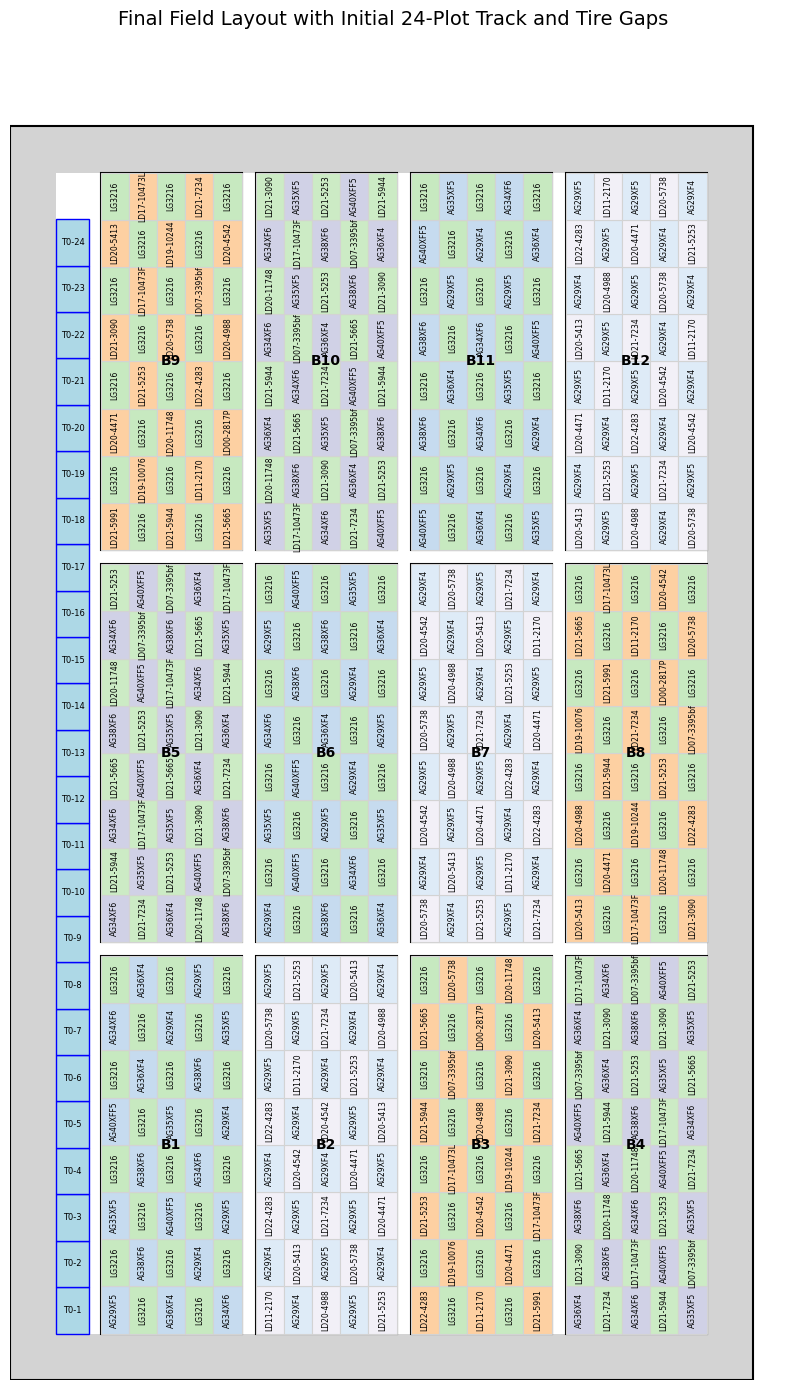

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import pandas as pd

# === Updated Field Setup ===
field_width = 160
field_height = 270
border_thickness = 10
initial_track_width = 7  # Updated width of the first track
tire_gap = 1.25  # Average tire gap width on either side

cols = 4
rows = 3
gap_x = 3
gap_y = 3

usable_width = field_width - 2 * border_thickness
usable_height = field_height - 2 * border_thickness

# Adjust width available for the rest of the blocks after the initial track and tire spacing
space_for_blocks = usable_width - initial_track_width - 2 * tire_gap - (cols - 1) * gap_x
block_width = space_for_blocks / cols
block_height = (usable_height - (rows - 1) * gap_y) / rows

cell_cols = 5
cell_rows = 8
cell_width = block_width / cell_cols
cell_height = block_height / cell_rows

# === Entry Definitions ===
designs = {
    1: {
        'A': ["AG29XF4", "AG29XF5", "AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': ["LG3216"],
        'A_COLOR': '#c6dbef',
        'B_COLOR': '#c7e9c0'
    },
    2: {
        'A': [
            "LD20-4542", "LD20-4988", "LD20-4471", "LD20-5738", "LD22-4283",
            "LD11-2170", "LD20-5413", "LD21-5253", "LD21-7234"
        ],
        'B': ["AG29XF4", "AG29XF5"],
        'A_COLOR': '#f2f0f7',
        'B_COLOR': '#deebf7'
    },
    3: {
        'A': [
            "LD11-2170", "LD20-4471", "LD20-4542", "LD20-4988", "LD20-5738", "LD22-4283",
            "LD00-2817P", "LD17-10473L", "LD19-10076", "LD19-10244", "LD21-5944", "LD21-5991",
            "LD07-3395bf", "LD17-10473F", "LD20-11748", "LD20-5413", "LD21-3090", "LD21-5253",
            "LD21-5665", "LD21-7234"
        ],
        'B': ["LG3216"],
        'A_COLOR': '#fdd0a2',
        'B_COLOR': '#c7e9c0'
    },
    4: {
        'A': ["AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': [
            "LD21-5253", "LD21-7234", "LD21-5665", "LD21-3090", "LD07-3395bf",
            "LD17-10473F", "LD20-11748", "LD21-5944"
        ],
        'A_COLOR': '#d0d1e6',
        'B_COLOR': '#ccebc5'
    }
}

# Recursive sampler
def recursive_sampler(pool):
    while True:
        shuffled = pool.copy()
        random.shuffle(shuffled)
        for entry in shuffled:
            yield entry

# === Drawing Layout ===
data = []
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((border_thickness, border_thickness),
                               usable_width, usable_height,
                               edgecolor='none', facecolor='white'))

# Add initial 24-plot track (Track 0) on the left
track_x = border_thickness
track_y = border_thickness
track_cell_height = 10  # 10 ft per plot
track_cell_width = initial_track_width

for i in range(24):
    y = track_y + i * track_cell_height
    ax.add_patch(patches.Rectangle((track_x, y), track_cell_width, track_cell_height,
                                   edgecolor='blue', facecolor='lightblue', linewidth=1))
    ax.text(track_x + track_cell_width / 2, y + track_cell_height / 2,
            f"T0-{i+1}", ha='center', va='center', fontsize=6)
    data.append({
        "Block": "T0",
        "Row": i,
        "Col": 0,
        "X": round(track_x + track_cell_width / 2, 2),
        "Y": round(y + track_cell_height / 2, 2),
        "Label": f"T0-{i+1}"
    })

# Draw the 12 randomized blocks, shifted after initial track and tire gaps
start_x = border_thickness + initial_track_width + 2 * tire_gap
design_blocks = {1: [1, 6, 11], 2: [2, 7, 12], 3: [3, 8, 9], 4: [4, 5, 10]}
block_id = 1

for i in range(rows):
    for j in range(cols):
        bl_x = start_x + j * (block_width + gap_x)
        bl_y = border_thickness + i * (block_height + gap_y)
        ax.add_patch(patches.Rectangle((bl_x, bl_y), block_width, block_height,
                                       edgecolor='black', facecolor='white', linewidth=1.5))

        design_idx = [d for d, blocks in design_blocks.items() if block_id in blocks]
        if design_idx:
            design = designs[design_idx[0]]
            a_gen = recursive_sampler(design['A'])
            b_gen = recursive_sampler(design['B'])

        for r in range(cell_rows):
            for c in range(cell_cols):
                cell_x = bl_x + c * cell_width
                cell_y = bl_y + r * cell_height

                if design_idx:
                    label = next(a_gen) if (r + c) % 2 == 0 else next(b_gen)
                    color = design['A_COLOR'] if (r + c) % 2 == 0 else design['B_COLOR']
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, cell_height,
                                                   edgecolor='lightgray', facecolor=color, linewidth=0.8))
                    ax.text(cell_x + cell_width / 2, cell_y + cell_height / 2, label,
                            ha='center', va='center', fontsize=5.5, rotation=90)
                else:
                    label = ""
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, cell_height,
                                                   edgecolor='lightgray', facecolor='none', linewidth=0.8))

                data.append({
                    "Block": f"B{block_id}",
                    "Row": r,
                    "Col": c,
                    "X": round(cell_x + cell_width / 2, 2),
                    "Y": round(cell_y + cell_height / 2, 2),
                    "Label": label
                })

        ax.text(bl_x + block_width / 2, bl_y + block_height / 2,
                f"B{block_id}", ha='center', va='center', fontsize=10, weight='bold')
        block_id += 1

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Initial 24-Plot Track and Tire Gaps", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show outputs
plt.savefig("final_field_design_with_tire_gaps.png")
df = pd.DataFrame(data)
df.to_csv("final_field_design_with_tire_gaps.csv", index=False)
plt.show()


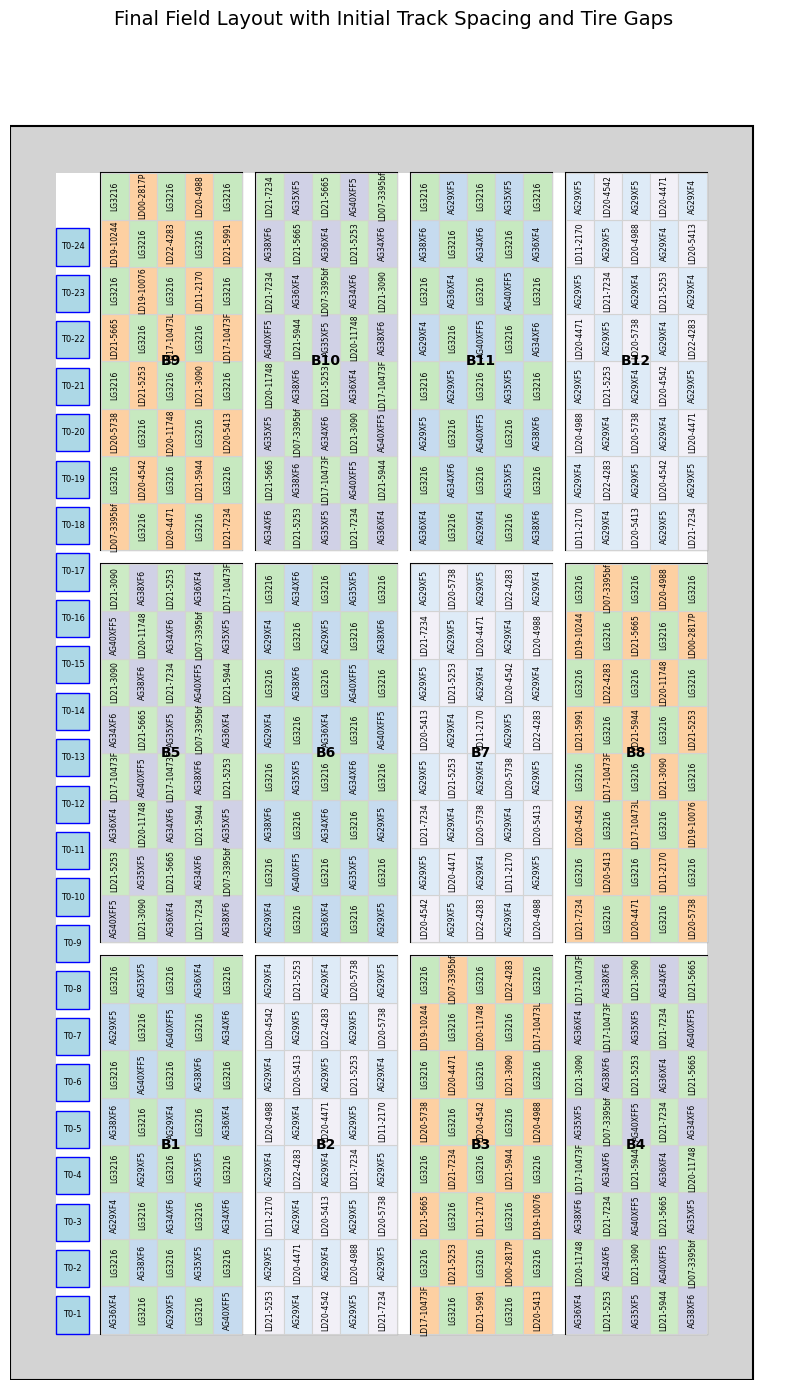

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import pandas as pd

# === Updated Field Setup ===
field_width = 160
field_height = 270
border_thickness = 10
initial_track_width = 7  # Width of the leftmost track
tire_gap = 1.25  # Average tire track on both sides of each pass
unplanted_space = 2  # Space between plots in Track 0

cols = 4
rows = 3
gap_x = 3
gap_y = 3

usable_width = field_width - 2 * border_thickness
usable_height = field_height - 2 * border_thickness

# Adjust available width for blocks
space_for_blocks = usable_width - initial_track_width - 2 * tire_gap - (cols - 1) * gap_x
block_width = space_for_blocks / cols
block_height = (usable_height - (rows - 1) * gap_y) / rows

cell_cols = 5
cell_rows = 8
cell_width = block_width / cell_cols
cell_height = block_height / cell_rows

# === Entry Definitions ===
designs = {
    1: {
        'A': ["AG29XF4", "AG29XF5", "AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': ["LG3216"],
        'A_COLOR': '#c6dbef',
        'B_COLOR': '#c7e9c0'
    },
    2: {
        'A': [
            "LD20-4542", "LD20-4988", "LD20-4471", "LD20-5738", "LD22-4283",
            "LD11-2170", "LD20-5413", "LD21-5253", "LD21-7234"
        ],
        'B': ["AG29XF4", "AG29XF5"],
        'A_COLOR': '#f2f0f7',
        'B_COLOR': '#deebf7'
    },
    3: {
        'A': [
            "LD11-2170", "LD20-4471", "LD20-4542", "LD20-4988", "LD20-5738", "LD22-4283",
            "LD00-2817P", "LD17-10473L", "LD19-10076", "LD19-10244", "LD21-5944", "LD21-5991",
            "LD07-3395bf", "LD17-10473F", "LD20-11748", "LD20-5413", "LD21-3090", "LD21-5253",
            "LD21-5665", "LD21-7234"
        ],
        'B': ["LG3216"],
        'A_COLOR': '#fdd0a2',
        'B_COLOR': '#c7e9c0'
    },
    4: {
        'A': ["AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': [
            "LD21-5253", "LD21-7234", "LD21-5665", "LD21-3090", "LD07-3395bf",
            "LD17-10473F", "LD20-11748", "LD21-5944"
        ],
        'A_COLOR': '#d0d1e6',
        'B_COLOR': '#ccebc5'
    }
}

# Recursive sampler
def recursive_sampler(pool):
    while True:
        shuffled = pool.copy()
        random.shuffle(shuffled)
        for entry in shuffled:
            yield entry

# === Drawing Layout ===
data = []
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((border_thickness, border_thickness),
                               usable_width, usable_height,
                               edgecolor='none', facecolor='white'))

# Draw initial Track 0 with spacing between plots
track_x = border_thickness
track_y = border_thickness
planted_length = 8  # 8 ft planted portion
alley = unplanted_space  # 2 ft space between plots

for i in range(24):
    y = track_y + i * (planted_length + alley)
    ax.add_patch(patches.Rectangle((track_x, y), initial_track_width, planted_length,
                                   edgecolor='blue', facecolor='lightblue', linewidth=1))
    ax.text(track_x + initial_track_width / 2, y + planted_length / 2,
            f"T0-{i+1}", ha='center', va='center', fontsize=6)
    data.append({
        "Block": "T0",
        "Row": i,
        "Col": 0,
        "X": round(track_x + initial_track_width / 2, 2),
        "Y": round(y + planted_length / 2, 2),
        "Label": f"T0-{i+1}"
    })

# Draw blocks to the right of Track 0
start_x = border_thickness + initial_track_width + 2 * tire_gap
design_blocks = {1: [1, 6, 11], 2: [2, 7, 12], 3: [3, 8, 9], 4: [4, 5, 10]}
block_id = 1

for i in range(rows):
    for j in range(cols):
        bl_x = start_x + j * (block_width + gap_x)
        bl_y = border_thickness + i * (block_height + gap_y)
        ax.add_patch(patches.Rectangle((bl_x, bl_y), block_width, block_height,
                                       edgecolor='black', facecolor='white', linewidth=1.5))

        design_idx = [d for d, blocks in design_blocks.items() if block_id in blocks]
        if design_idx:
            design = designs[design_idx[0]]
            a_gen = recursive_sampler(design['A'])
            b_gen = recursive_sampler(design['B'])

        for r in range(cell_rows):
            for c in range(cell_cols):
                cell_x = bl_x + c * cell_width
                cell_y = bl_y + r * cell_height

                if design_idx:
                    label = next(a_gen) if (r + c) % 2 == 0 else next(b_gen)
                    color = design['A_COLOR'] if (r + c) % 2 == 0 else design['B_COLOR']
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, cell_height,
                                                   edgecolor='lightgray', facecolor=color, linewidth=0.8))
                    ax.text(cell_x + cell_width / 2, cell_y + cell_height / 2, label,
                            ha='center', va='center', fontsize=5.5, rotation=90)
                else:
                    label = ""
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, cell_height,
                                                   edgecolor='lightgray', facecolor='none', linewidth=0.8))

                data.append({
                    "Block": f"B{block_id}",
                    "Row": r,
                    "Col": c,
                    "X": round(cell_x + cell_width / 2, 2),
                    "Y": round(cell_y + cell_height / 2, 2),
                    "Label": label
                })

        ax.text(bl_x + block_width / 2, bl_y + block_height / 2,
                f"B{block_id}", ha='center', va='center', fontsize=10, weight='bold')
        block_id += 1

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Initial Track Spacing and Tire Gaps", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show outputs
plt.savefig("final_field_design_with_spacing_and_tire_gaps.png")
df = pd.DataFrame(data)
df.to_csv("final_field_design_with_spacing_and_tire_gaps.csv", index=False)
plt.show()


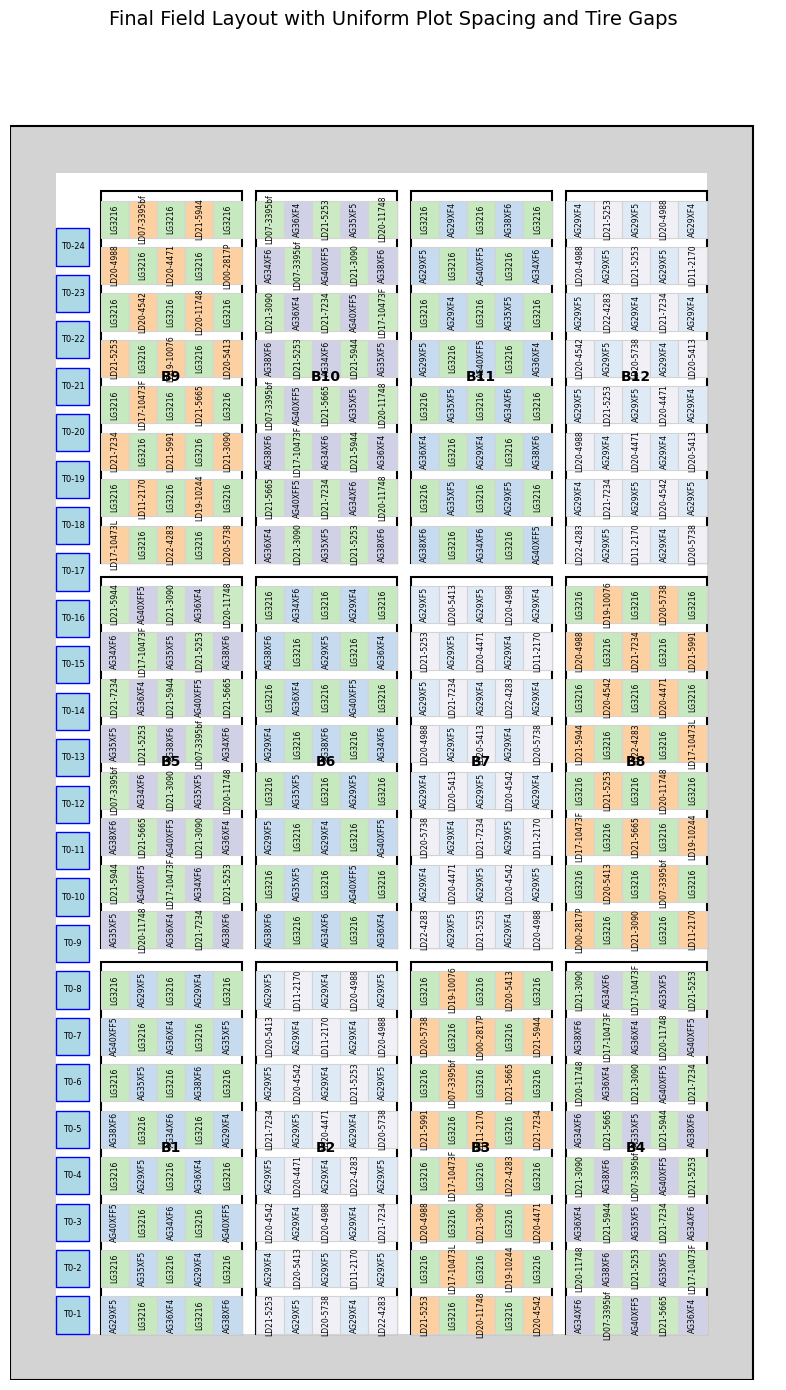

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import pandas as pd

# === Updated Field Setup ===
field_width = 160
field_height = 270
border_thickness = 10
initial_track_width = 7  # Width of the leftmost track
tire_gap = 1.25  # Average tire track on both sides of each pass
unplanted_space = 2  # Space between plots
planted_length = 8  # Planted portion per plot

cols = 4
rows = 3
gap_x = 3
gap_y = 3
plots_per_col = 8  # Number of plots per vertical block

usable_width = field_width - 2 * border_thickness
usable_height = field_height - 2 * border_thickness

# Adjust available width for blocks
space_for_blocks = usable_width - initial_track_width - 2 * tire_gap - (cols - 1) * gap_x
block_width = space_for_blocks / cols

# Adjusted block height with spacing between plots
block_height = plots_per_col * (planted_length + unplanted_space)
cell_cols = 5
cell_width = block_width / cell_cols
cell_height = planted_length

# === Entry Definitions ===
designs = {
    1: {
        'A': ["AG29XF4", "AG29XF5", "AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': ["LG3216"],
        'A_COLOR': '#c6dbef',
        'B_COLOR': '#c7e9c0'
    },
    2: {
        'A': [
            "LD20-4542", "LD20-4988", "LD20-4471", "LD20-5738", "LD22-4283",
            "LD11-2170", "LD20-5413", "LD21-5253", "LD21-7234"
        ],
        'B': ["AG29XF4", "AG29XF5"],
        'A_COLOR': '#f2f0f7',
        'B_COLOR': '#deebf7'
    },
    3: {
        'A': [
            "LD11-2170", "LD20-4471", "LD20-4542", "LD20-4988", "LD20-5738", "LD22-4283",
            "LD00-2817P", "LD17-10473L", "LD19-10076", "LD19-10244", "LD21-5944", "LD21-5991",
            "LD07-3395bf", "LD17-10473F", "LD20-11748", "LD20-5413", "LD21-3090", "LD21-5253",
            "LD21-5665", "LD21-7234"
        ],
        'B': ["LG3216"],
        'A_COLOR': '#fdd0a2',
        'B_COLOR': '#c7e9c0'
    },
    4: {
        'A': ["AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': [
            "LD21-5253", "LD21-7234", "LD21-5665", "LD21-3090", "LD07-3395bf",
            "LD17-10473F", "LD20-11748", "LD21-5944"
        ],
        'A_COLOR': '#d0d1e6',
        'B_COLOR': '#ccebc5'
    }
}

# Recursive sampler
def recursive_sampler(pool):
    while True:
        shuffled = pool.copy()
        random.shuffle(shuffled)
        for entry in shuffled:
            yield entry

# === Drawing Layout ===
data = []
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((border_thickness, border_thickness),
                               usable_width, usable_height,
                               edgecolor='none', facecolor='white'))

# Draw initial Track 0
track_x = border_thickness
track_y = border_thickness

for i in range(24):
    y = track_y + i * (planted_length + unplanted_space)
    ax.add_patch(patches.Rectangle((track_x, y), initial_track_width, planted_length,
                                   edgecolor='blue', facecolor='lightblue', linewidth=1))
    ax.text(track_x + initial_track_width / 2, y + planted_length / 2,
            f"T0-{i+1}", ha='center', va='center', fontsize=6)
    data.append({
        "Block": "T0",
        "Row": i,
        "Col": 0,
        "X": round(track_x + initial_track_width / 2, 2),
        "Y": round(y + planted_length / 2, 2),
        "Label": f"T0-{i+1}"
    })

# Draw blocks to the right of Track 0
start_x = border_thickness + initial_track_width + 2 * tire_gap
design_blocks = {1: [1, 6, 11], 2: [2, 7, 12], 3: [3, 8, 9], 4: [4, 5, 10]}
block_id = 1

for i in range(rows):
    for j in range(cols):
        bl_x = start_x + j * (block_width + gap_x)
        bl_y = border_thickness + i * (block_height + gap_y)
        ax.add_patch(patches.Rectangle((bl_x, bl_y), block_width, block_height,
                                       edgecolor='black', facecolor='white', linewidth=1.5))

        design_idx = [d for d, blocks in design_blocks.items() if block_id in blocks]
        if design_idx:
            design = designs[design_idx[0]]
            a_gen = recursive_sampler(design['A'])
            b_gen = recursive_sampler(design['B'])

        for r in range(plots_per_col):
            for c in range(cell_cols):
                cell_x = bl_x + c * cell_width
                cell_y = bl_y + r * (planted_length + unplanted_space)

                if design_idx:
                    label = next(a_gen) if (r + c) % 2 == 0 else next(b_gen)
                    color = design['A_COLOR'] if (r + c) % 2 == 0 else design['B_COLOR']
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor=color, linewidth=0.8))
                    ax.text(cell_x + cell_width / 2, cell_y + planted_length / 2, label,
                            ha='center', va='center', fontsize=5.5, rotation=90)
                else:
                    label = ""
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor='none', linewidth=0.8))

                data.append({
                    "Block": f"B{block_id}",
                    "Row": r,
                    "Col": c,
                    "X": round(cell_x + cell_width / 2, 2),
                    "Y": round(cell_y + planted_length / 2, 2),
                    "Label": label
                })

        ax.text(bl_x + block_width / 2, bl_y + block_height / 2,
                f"B{block_id}", ha='center', va='center', fontsize=10, weight='bold')
        block_id += 1

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Uniform Plot Spacing and Tire Gaps", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show outputs
plt.savefig("final_field_design_uniform_spacing.png")
df = pd.DataFrame(data)
df.to_csv("final_field_design_uniform_spacing.csv", index=False)
plt.show()


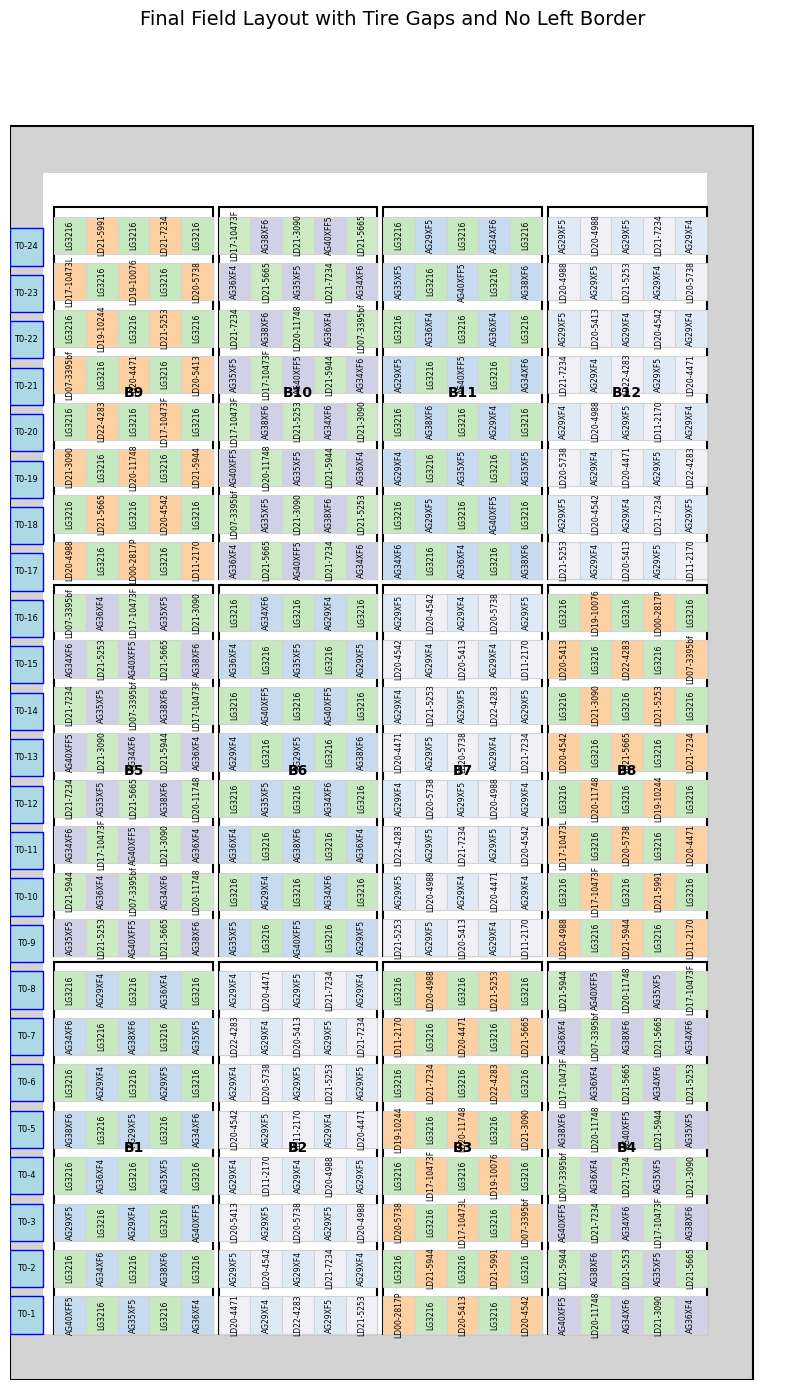

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import pandas as pd

# === Final Field Setup ===
field_width = 160
field_height = 270
border_thickness = 10  # Top, bottom, and right borders only
track0_width = 7  # Track 0 serves as left border
tire_gap = 1.25  # Gap between all planter passes
unplanted_space = 2  # Space between plots
planted_length = 8  # Planted row length
plots_per_col = 8  # Number of rows per block

cols = 4
rows = 3
cell_cols = 5

# Calculate usable area
usable_width = field_width - border_thickness - track0_width - 2 * tire_gap
usable_height = field_height - 2 * border_thickness

# Block and cell sizes
block_width = (usable_width - (cols - 1) * tire_gap) / cols
block_height = plots_per_col * (planted_length + unplanted_space)
cell_width = block_width / cell_cols
cell_height = planted_length

# === Entry Definitions ===
designs = {
    1: {
        'A': ["AG29XF4", "AG29XF5", "AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': ["LG3216"],
        'A_COLOR': '#c6dbef',
        'B_COLOR': '#c7e9c0'
    },
    2: {
        'A': [
            "LD20-4542", "LD20-4988", "LD20-4471", "LD20-5738", "LD22-4283",
            "LD11-2170", "LD20-5413", "LD21-5253", "LD21-7234"
        ],
        'B': ["AG29XF4", "AG29XF5"],
        'A_COLOR': '#f2f0f7',
        'B_COLOR': '#deebf7'
    },
    3: {
        'A': [
            "LD11-2170", "LD20-4471", "LD20-4542", "LD20-4988", "LD20-5738", "LD22-4283",
            "LD00-2817P", "LD17-10473L", "LD19-10076", "LD19-10244", "LD21-5944", "LD21-5991",
            "LD07-3395bf", "LD17-10473F", "LD20-11748", "LD20-5413", "LD21-3090", "LD21-5253",
            "LD21-5665", "LD21-7234"
        ],
        'B': ["LG3216"],
        'A_COLOR': '#fdd0a2',
        'B_COLOR': '#c7e9c0'
    },
    4: {
        'A': ["AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': [
            "LD21-5253", "LD21-7234", "LD21-5665", "LD21-3090", "LD07-3395bf",
            "LD17-10473F", "LD20-11748", "LD21-5944"
        ],
        'A_COLOR': '#d0d1e6',
        'B_COLOR': '#ccebc5'
    }
}

# Recursive sampler
def recursive_sampler(pool):
    while True:
        shuffled = pool.copy()
        random.shuffle(shuffled)
        for entry in shuffled:
            yield entry

# === Drawing Layout ===
data = []
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((track0_width, border_thickness),
                               field_width - track0_width - border_thickness,
                               usable_height,
                               edgecolor='none', facecolor='white'))

# Draw Track 0 (left edge, no additional border)
track_x = 0
track_y = border_thickness

for i in range(24):
    y = track_y + i * (planted_length + unplanted_space)
    ax.add_patch(patches.Rectangle((track_x, y), track0_width, planted_length,
                                   edgecolor='blue', facecolor='lightblue', linewidth=1))
    ax.text(track_x + track0_width / 2, y + planted_length / 2,
            f"T0-{i+1}", ha='center', va='center', fontsize=6)
    data.append({
        "Block": "T0",
        "Row": i,
        "Col": 0,
        "X": round(track_x + track0_width / 2, 2),
        "Y": round(y + planted_length / 2, 2),
        "Label": f"T0-{i+1}"
    })

# Draw randomized blocks to the right of Track 0
start_x = track0_width + 2 * tire_gap
design_blocks = {1: [1, 6, 11], 2: [2, 7, 12], 3: [3, 8, 9], 4: [4, 5, 10]}
block_id = 1

for i in range(rows):
    for j in range(cols):
        bl_x = start_x + j * (block_width + tire_gap)
        bl_y = border_thickness + i * (block_height + tire_gap)
        ax.add_patch(patches.Rectangle((bl_x, bl_y), block_width, block_height,
                                       edgecolor='black', facecolor='white', linewidth=1.5))

        design_idx = [d for d, blocks in design_blocks.items() if block_id in blocks]
        if design_idx:
            design = designs[design_idx[0]]
            a_gen = recursive_sampler(design['A'])
            b_gen = recursive_sampler(design['B'])

        for r in range(plots_per_col):
            for c in range(cell_cols):
                cell_x = bl_x + c * cell_width
                cell_y = bl_y + r * (planted_length + unplanted_space)

                if design_idx:
                    label = next(a_gen) if (r + c) % 2 == 0 else next(b_gen)
                    color = design['A_COLOR'] if (r + c) % 2 == 0 else design['B_COLOR']
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor=color, linewidth=0.8))
                    ax.text(cell_x + cell_width / 2, cell_y + planted_length / 2, label,
                            ha='center', va='center', fontsize=5.5, rotation=90)
                else:
                    label = ""
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor='none', linewidth=0.8))

                data.append({
                    "Block": f"B{block_id}",
                    "Row": r,
                    "Col": c,
                    "X": round(cell_x + cell_width / 2, 2),
                    "Y": round(cell_y + planted_length / 2, 2),
                    "Label": label
                })

        ax.text(bl_x + block_width / 2, bl_y + block_height / 2,
                f"B{block_id}", ha='center', va='center', fontsize=10, weight='bold')
        block_id += 1

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Tire Gaps and No Left Border", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show outputs
plt.savefig("final_field_layout_no_left_border.png")
df = pd.DataFrame(data)
df.to_csv("final_field_layout_no_left_border.csv", index=False)
plt.show()


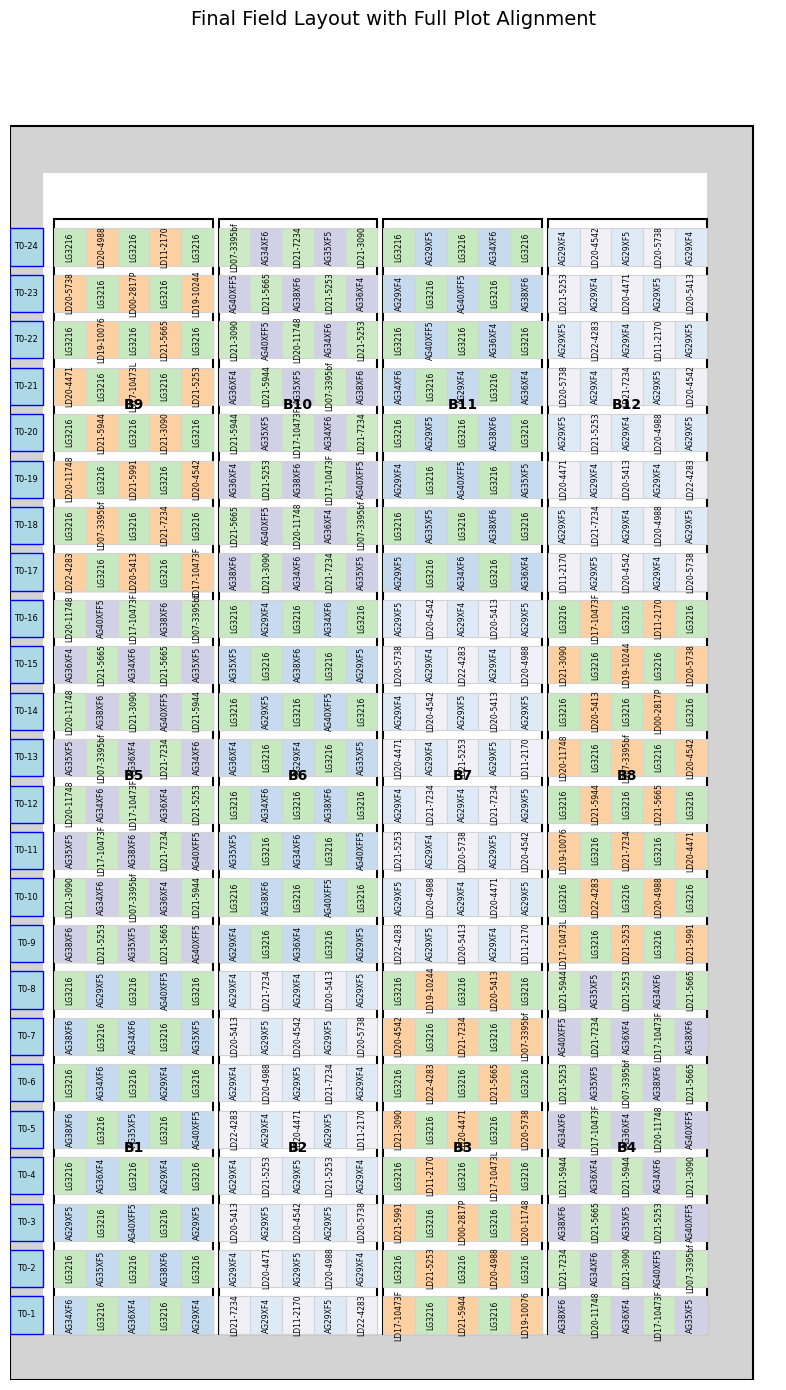

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import pandas as pd

# === Final Field Setup ===
field_width = 160
field_height = 270
border_thickness = 10  # Only top, bottom, and right
track0_width = 7
tire_gap = 1.25
unplanted_space = 2
planted_length = 8
plots_per_col = 8
cell_cols = 5
cols = 4
rows = 3

# Derived sizes
usable_width = field_width - border_thickness - track0_width - 2 * tire_gap
usable_height = field_height - 2 * border_thickness
block_width = (usable_width - (cols - 1) * tire_gap) / cols
block_height = plots_per_col * (planted_length + unplanted_space)
cell_width = block_width / cell_cols
cell_height = planted_length

# === Entry Definitions ===
designs = {
    1: {
        'A': ["AG29XF4", "AG29XF5", "AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': ["LG3216"],
        'A_COLOR': '#c6dbef',
        'B_COLOR': '#c7e9c0'
    },
    2: {
        'A': [
            "LD20-4542", "LD20-4988", "LD20-4471", "LD20-5738", "LD22-4283",
            "LD11-2170", "LD20-5413", "LD21-5253", "LD21-7234"
        ],
        'B': ["AG29XF4", "AG29XF5"],
        'A_COLOR': '#f2f0f7',
        'B_COLOR': '#deebf7'
    },
    3: {
        'A': [
            "LD11-2170", "LD20-4471", "LD20-4542", "LD20-4988", "LD20-5738", "LD22-4283",
            "LD00-2817P", "LD17-10473L", "LD19-10076", "LD19-10244", "LD21-5944", "LD21-5991",
            "LD07-3395bf", "LD17-10473F", "LD20-11748", "LD20-5413", "LD21-3090", "LD21-5253",
            "LD21-5665", "LD21-7234"
        ],
        'B': ["LG3216"],
        'A_COLOR': '#fdd0a2',
        'B_COLOR': '#c7e9c0'
    },
    4: {
        'A': ["AG34XF6", "AG35XF5", "AG36XF4", "AG38XF6", "AG40XFF5"],
        'B': [
            "LD21-5253", "LD21-7234", "LD21-5665", "LD21-3090", "LD07-3395bf",
            "LD17-10473F", "LD20-11748", "LD21-5944"
        ],
        'A_COLOR': '#d0d1e6',
        'B_COLOR': '#ccebc5'
    }
}

def recursive_sampler(pool):
    while True:
        shuffled = pool.copy()
        random.shuffle(shuffled)
        for entry in shuffled:
            yield entry

# === Drawing Layout ===
data = []
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((track0_width, border_thickness),
                               field_width - track0_width - border_thickness,
                               usable_height,
                               edgecolor='none', facecolor='white'))

# Track 0: aligned to vertical grid, no left border
track_x = 0
track_y = border_thickness
for i in range(24):
    y = track_y + i * (planted_length + unplanted_space)
    ax.add_patch(patches.Rectangle((track_x, y), track0_width, planted_length,
                                   edgecolor='blue', facecolor='lightblue', linewidth=1))
    ax.text(track_x + track0_width / 2, y + planted_length / 2,
            f"T0-{i+1}", ha='center', va='center', fontsize=6)
    data.append({
        "Block": "T0",
        "Row": i,
        "Col": 0,
        "X": round(track_x + track0_width / 2, 2),
        "Y": round(y + planted_length / 2, 2),
        "Label": f"T0-{i+1}"
    })

# Randomized blocks: NO vertical gaps, all plots align horizontally with Track 0
start_x = track0_width + 2 * tire_gap
design_blocks = {1: [1, 6, 11], 2: [2, 7, 12], 3: [3, 8, 9], 4: [4, 5, 10]}
block_id = 1

for i in range(rows):
    for j in range(cols):
        bl_x = start_x + j * (block_width + tire_gap)
        bl_y = border_thickness + i * block_height  # no horizontal gap
        ax.add_patch(patches.Rectangle((bl_x, bl_y), block_width, block_height,
                                       edgecolor='black', facecolor='white', linewidth=1.5))

        design_idx = [d for d, blocks in design_blocks.items() if block_id in blocks]
        if design_idx:
            design = designs[design_idx[0]]
            a_gen = recursive_sampler(design['A'])
            b_gen = recursive_sampler(design['B'])

        for r in range(plots_per_col):
            for c in range(cell_cols):
                cell_x = bl_x + c * cell_width
                cell_y = bl_y + r * (planted_length + unplanted_space)

                if design_idx:
                    label = next(a_gen) if (r + c) % 2 == 0 else next(b_gen)
                    color = design['A_COLOR'] if (r + c) % 2 == 0 else design['B_COLOR']
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor=color, linewidth=0.8))
                    ax.text(cell_x + cell_width / 2, cell_y + planted_length / 2, label,
                            ha='center', va='center', fontsize=5.5, rotation=90)
                else:
                    label = ""
                    ax.add_patch(patches.Rectangle((cell_x, cell_y), cell_width, planted_length,
                                                   edgecolor='lightgray', facecolor='none', linewidth=0.8))

                data.append({
                    "Block": f"B{block_id}",
                    "Row": r,
                    "Col": c,
                    "X": round(cell_x + cell_width / 2, 2),
                    "Y": round(cell_y + planted_length / 2, 2),
                    "Label": label
                })

        ax.text(bl_x + block_width / 2, bl_y + block_height / 2,
                f"B{block_id}", ha='center', va='center', fontsize=10, weight='bold')
        block_id += 1

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Full Plot Alignment", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show outputs
plt.savefig("final_field_layout_full_alignment.png")
df = pd.DataFrame(data)
df.to_csv("final_field_layout_full_alignment.csv", index=False)
plt.show()


/tmp/ipython-input-7-1524140870.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_labels))


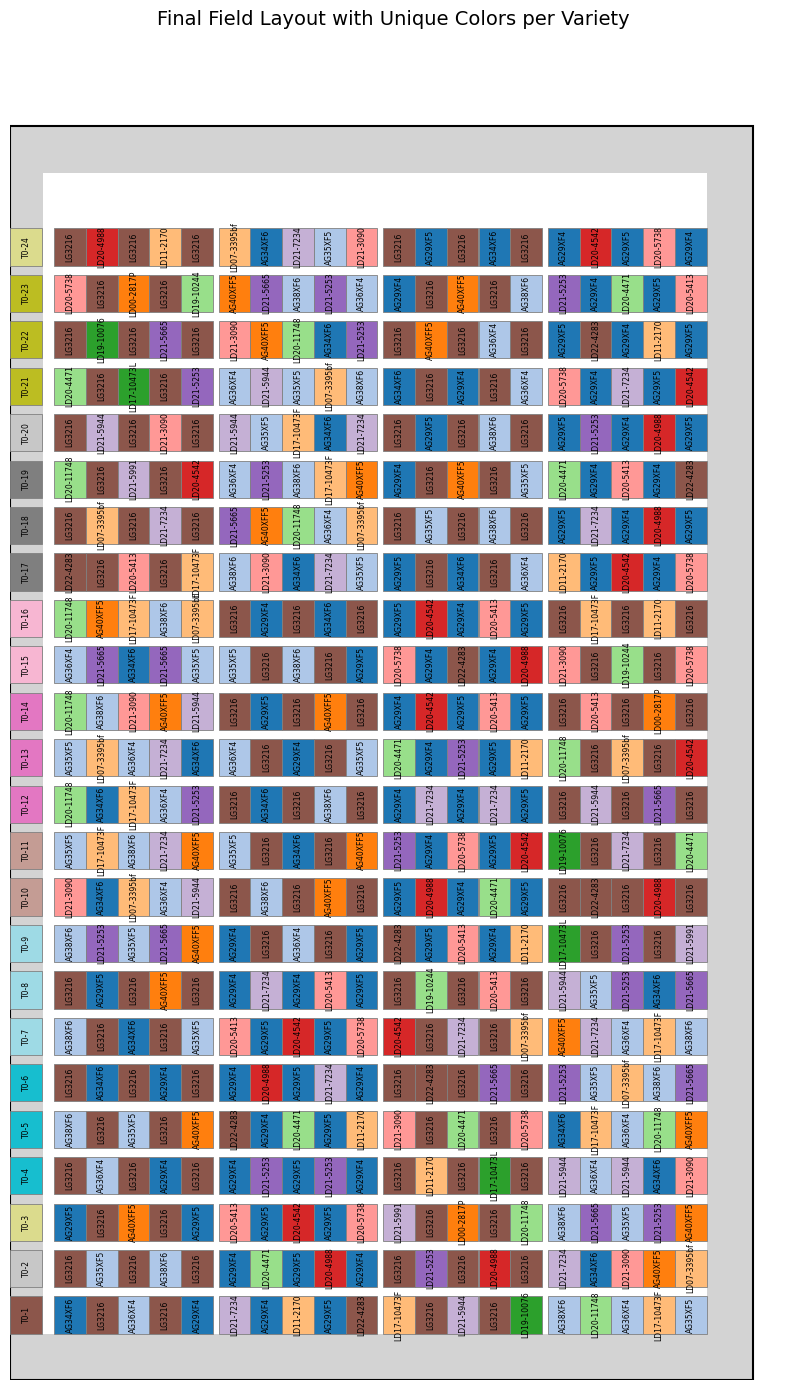

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Load the previous data with plot information
df = pd.read_csv("final_field_layout_full_alignment.csv")

# Generate unique colors for each unique label
unique_labels = sorted(df['Label'].unique())
cmap = cm.get_cmap('tab20', len(unique_labels))
color_map = {label: mcolors.to_hex(cmap(i)) for i, label in enumerate(unique_labels)}

# Create the new plot
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((track0_width, border_thickness),
                               field_width - track0_width - border_thickness,
                               usable_height,
                               edgecolor='none', facecolor='white'))

# Draw all plots from the dataframe
for _, row in df.iterrows():
    x = row['X'] - cell_width / 2
    y = row['Y'] - planted_length / 2
    label = row['Label']
    color = color_map[label]
    ax.add_patch(patches.Rectangle((x, y), cell_width, planted_length,
                                   edgecolor='gray', facecolor=color, linewidth=0.6))
    ax.text(x + cell_width / 2, y + planted_length / 2, label,
            ha='center', va='center', fontsize=5.5, rotation=90)

# Finalize layout
ax.set_xlim(0, field_width + 5)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Unique Colors per Variety", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and display
plt.savefig("final_field_layout_unique_colors.png")
plt.show()


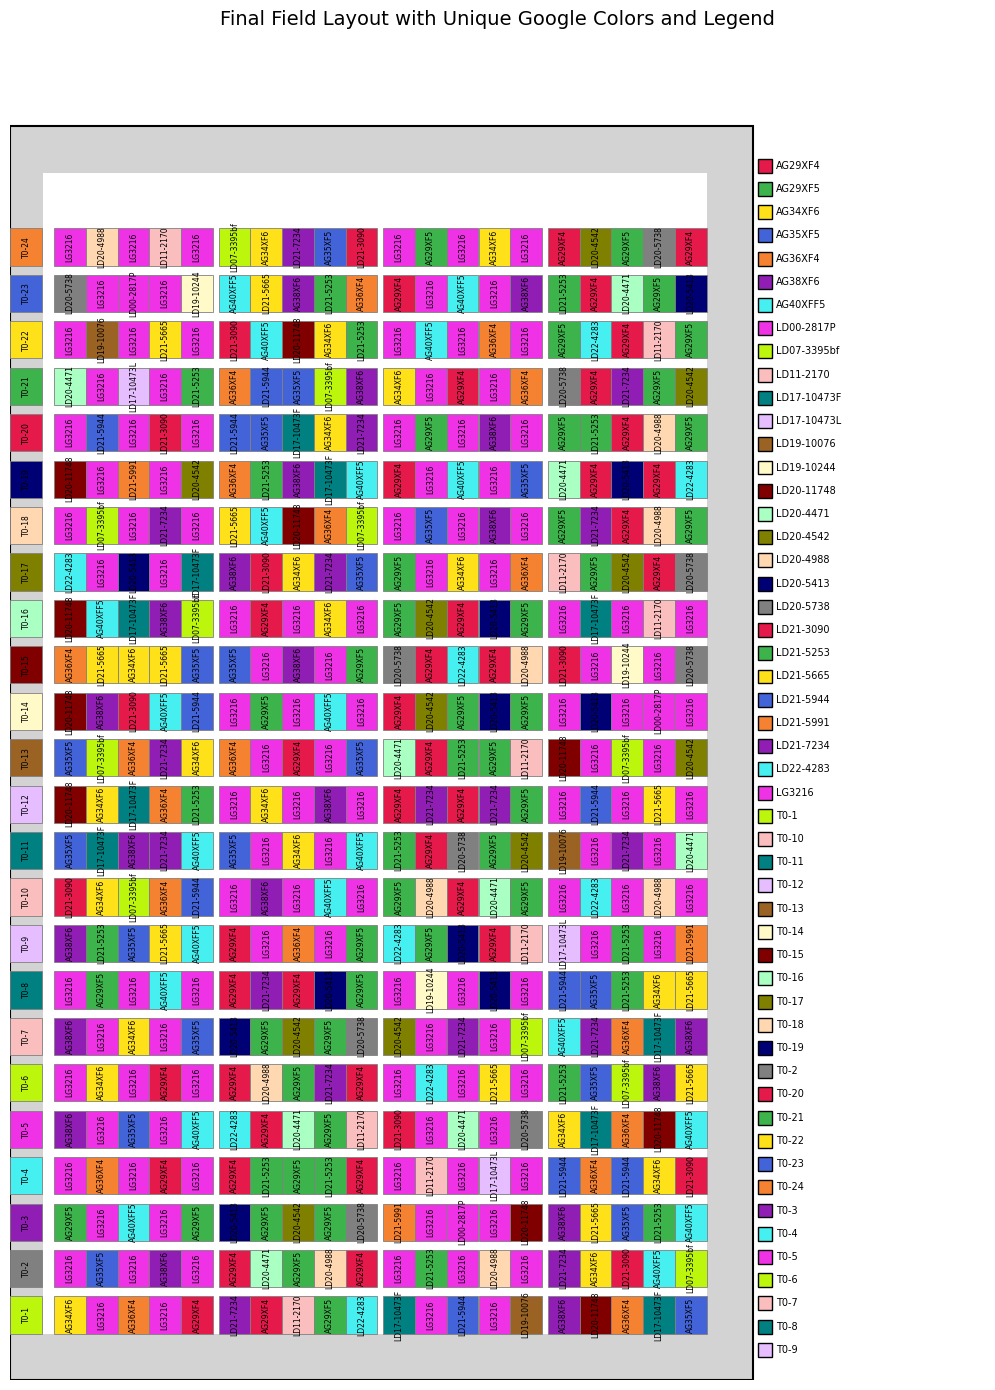

In [ ]:
# Update to google colors
# Use Google's Material Design color palette
google_colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
    "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000",
    "#aaffc3", "#808000", "#ffd8b1", "#000075", "#808080"
]

# Update color map using Google colors
color_map_google = {label: google_colors[i % len(google_colors)] for i, label in enumerate(unique_labels)}

# Create the plot with the updated color map and a legend
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((track0_width, border_thickness),
                               field_width - track0_width - border_thickness,
                               usable_height,
                               edgecolor='none', facecolor='white'))

# Draw plots
for _, row in df.iterrows():
    x = row['X'] - cell_width / 2
    y = row['Y'] - planted_length / 2
    label = row['Label']
    color = color_map_google[label]
    ax.add_patch(patches.Rectangle((x, y), cell_width, planted_length,
                                   edgecolor='gray', facecolor=color, linewidth=0.6))
    ax.text(x + cell_width / 2, y + planted_length / 2, label,
            ha='center', va='center', fontsize=5.5, rotation=90)

# Add legend
legend_x = field_width + 1
legend_y_start = field_height - 10
legend_spacing = 5

for i, label in enumerate(unique_labels):
    y_pos = legend_y_start - i * legend_spacing
    ax.add_patch(patches.Rectangle((legend_x, y_pos), 3, 3, facecolor=color_map_google[label], edgecolor='black'))
    ax.text(legend_x + 4, y_pos + 1.5, label, va='center', fontsize=7)

# Finalize layout
ax.set_xlim(0, field_width + 50)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Final Field Layout with Unique Google Colors and Legend", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and show the figure
plt.savefig("final_field_layout_google_colors_legend.png")
plt.show()


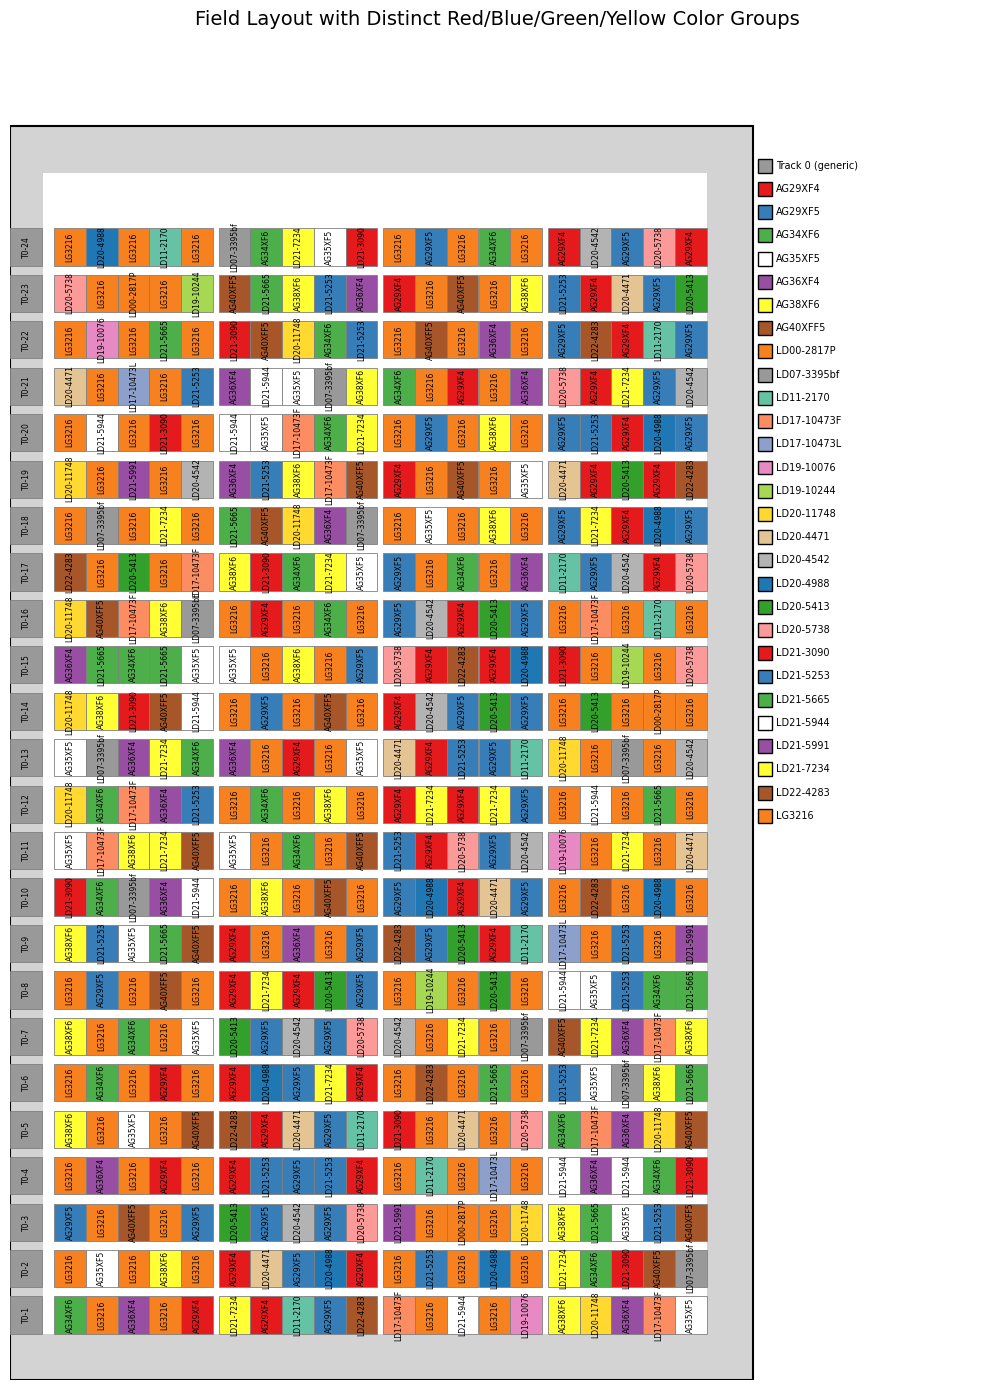

In [ ]:
# Choose a distinct and vibrant palette manually combining red, blue, green, yellow families
# Assign a neutral gray tone for all Track 0 plots
track0_color = "#999999"

custom_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#ffffff",  # Red, Blue, Green, Orange
    "#984ea3", "#ffff33", "#a65628", "#f7811f",  # Purple, Yellow, Brown, Pink
    "#999999", "#66c2a5", "#fc8d62", "#8da0cb",  # Teal, Coral, Lavender
    "#e78ac3", "#a6d854", "#ffd92f", "#e5c494",  # Magenta, Lime, Gold, Tan
    "#b3b3b3", "#1f78b4", "#33a02c", "#fb9a99"   # Gray, Blue, Green, Salmon
]

# Cycle through if needed
color_map_custom = {label: custom_colors[i % len(custom_colors)] for i, label in enumerate(unique_labels)}

# Create the updated plot
fig, ax = plt.subplots(figsize=(14, 14))
ax.add_patch(patches.Rectangle((0, 0), field_width, field_height,
                               edgecolor='black', facecolor='lightgray', linewidth=1.5))
ax.add_patch(patches.Rectangle((track0_width, border_thickness),
                               field_width - track0_width - border_thickness,
                               usable_height,
                               edgecolor='none', facecolor='white'))

# Draw plots with Track 0 in gray and others in distinct color groups
for _, row in df.iterrows():
    x = row['X'] - cell_width / 2
    y = row['Y'] - planted_length / 2
    label = row['Label']
    if row['Block'] == 'T0':
        color = track0_color
    else:
        color = color_map_custom[label]
    ax.add_patch(patches.Rectangle((x, y), cell_width, planted_length,
                                   edgecolor='gray', facecolor=color, linewidth=0.6))
    ax.text(x + cell_width / 2, y + planted_length / 2, label,
            ha='center', va='center', fontsize=5.5, rotation=90)

# Add legend
legend_x = field_width + 1
legend_y_start = field_height - 10
legend_spacing = 5

# Track 0 entry
ax.add_patch(patches.Rectangle((legend_x, legend_y_start), 3, 3, facecolor=track0_color, edgecolor='black'))
ax.text(legend_x + 4, legend_y_start + 1.5, "Track 0 (generic)", va='center', fontsize=7)

# Remaining variety entries
offset = 1
for i, label in enumerate(unique_labels):
    if label in df[df['Block'] == 'T0']['Label'].values:
        continue
    y_pos = legend_y_start - offset * legend_spacing
    ax.add_patch(patches.Rectangle((legend_x, y_pos), 3, 3, facecolor=color_map_custom[label], edgecolor='black'))
    ax.text(legend_x + 4, y_pos + 1.5, label, va='center', fontsize=7)
    offset += 1

# Finalize layout
ax.set_xlim(0, field_width + 50)
ax.set_ylim(0, field_height + 20)
ax.set_aspect('equal')
ax.set_title("Field Layout with Distinct Red/Blue/Green/Yellow Color Groups", fontsize=14)
ax.axis('off')
plt.tight_layout()

# Save and display
plt.savefig("final_field_layout_distinct_color_groups.png")
plt.show()


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
import numpy as np
track0_color = "#999999"

custom_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#ffffff",  # Red, Blue, Green, Orange
    "#984ea3", "#ffff33", "#a65628", "#f7811f",  # Purple, Yellow, Brown, Pink
    "#999999", "#66c2a5", "#fc8d62", "#8da0cb",  # Teal, Coral, Lavender
    "#e78ac3", "#a6d854", "#ffd92f", "#e5c494",  # Magenta, Lime, Gold, Tan
    "#b3b3b3", "#1f78b4", "#33a02c", "#fb9a99"   # Gray, Blue, Green, Salmon
]

# Cycle through if needed
color_map_custom = {label: custom_colors[i % len(custom_colors)] for i, label in enumerate(unique_labels)}

# Prepare coordinates for start and stop positions
df['X_start'] = df['X'] - cell_width / 2
df['X_stop'] = df['X'] + cell_width / 2
df['Y_start'] = df['Y'] - planted_length / 2
df['Y_stop'] = df['Y'] + planted_length / 2

# Create an A5-sized multipage PDF
pdf_path = "FieldBook_A5_FieldLayout.pdf"
pdf = PdfPages(pdf_path)

# Convert inches: A5 size ~ 5.8 x 8.3 inches
a5_inches = (5.8, 8.3)

# Page 1: Overall field map
fig1 = plt.figure(figsize=a5_inches)
plt.imshow(plt.imread("final_field_layout_distinct_color_groups.png"))
plt.axis('off')
plt.title("Overall Field Map", fontsize=10)
pdf.savefig(fig1)
plt.close(fig1)

# Page 2: Entry list table
fig2, ax2 = plt.subplots(figsize=a5_inches)
entry_list = df[df['Block'] != 'T0'][['Label']].drop_duplicates().reset_index(drop=True)
entry_list.index = entry_list.index + 1
ax2.axis('off')
table_data = [["Entry#", "Label"]] + [[i, row.Label] for i, row in entry_list.iterrows()]
table = ax2.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.2, 0.8])
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 1.5)
plt.title("Entry List", fontsize=10)
pdf.savefig(fig2)
plt.close(fig2)

# Pages 3+: One per block with block layout and coordinate table
blocks = sorted(df[df['Block'] != 'T0']['Block'].unique(), key=lambda x: int(x[1:]))
for block in blocks:
    block_df = df[df['Block'] == block].copy()

    # Block map
    fig, ax = plt.subplots(figsize=a5_inches)
    for _, row in block_df.iterrows():
        color = track0_color if row['Block'] == 'T0' else color_map_custom.get(row['Label'], "#ffffff")
        ax.add_patch(patches.Rectangle((row['X_start'], row['Y_start']),
                                       cell_width, planted_length,
                                       facecolor=color, edgecolor='gray'))
        ax.text(row['X'], row['Y'], row['Label'], ha='center', va='center', fontsize=4, rotation=90)
    ax.set_xlim(df['X_start'].min() - 1, df['X_stop'].max() + 1)
    ax.set_ylim(df['Y_start'].min() - 1, df['Y_stop'].max() + 1)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.title(f"Block {block} Layout", fontsize=10)
    pdf.savefig(fig)
    plt.close(fig)

    # Block coordinate table
    fig_table, ax_table = plt.subplots(figsize=a5_inches)
    ax_table.axis('off')
    coords_data = block_df[['Row', 'Col', 'Label', 'X_start', 'Y_start', 'X_stop', 'Y_stop']]
    coords_data = coords_data.sort_values(by=['Row', 'Col'])
    headers = ["Row", "Col", "Label", "X_start", "Y_start", "X_stop", "Y_stop"]
    table_vals = [headers] + coords_data.round(2).values.tolist()
    table = ax_table.table(cellText=table_vals, loc='center', cellLoc='left', colWidths=[0.1, 0.1, 0.3, 0.2, 0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(5)
    table.scale(1, 1.3)
    plt.title(f"Block {block} Plot Coordinates", fontsize=10)
    pdf.savefig(fig_table)
    plt.close(fig_table)

pdf.close()
pdf_path


'FieldBook_A5_FieldLayout.pdf'